# Transfer Learning y Fine-Tuning

In [1]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

import csv
import os
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## Dataset

In [3]:
class FoodDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        with open(csv_path) as f:
            reader = csv.DictReader(f)
            self.samples = [(row["filename"], int(row["class_idx"])) for row in reader]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [4]:
transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224,
   0.225]),
  ])

In [5]:
dataset = FoodDataset("data/labels.csv", "data/images", transform=transform)

In [6]:
n = len(dataset)
train_size = int(0.8 * n)
val_size   = int(0.1 * n)
test_size  = n - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

In [7]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

In [8]:
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes: {{'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}}")

Train: 168 | Val: 21 | Test: 21
Classes: {'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}


In [9]:
num_classes = 4

## Pre-trained Models

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        print(f"Epoch {epoch+1}/{_num_epochs} — "
              f"train_loss: {epoch_train_loss:.4f}  train_acc: {train_acc:.4f}  "
              f"val_loss: {epoch_val_loss:.4f}  val_acc: {val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [12]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### ResNet50

In [13]:
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

In [14]:
weights = ResNet50_Weights.DEFAULT
model1 = resnet50(weights=weights)

model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

#### Transfer Learning

In [15]:
# 2. Freeze all parameters
for param in model1.parameters():
    param.requires_grad = False

In [16]:
# 3. Replace the final classifier (ResNet uses model.fc, not model.classifier)
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

In [17]:
optimizer = torch.optim.Adam(model1.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [18]:
res = train(model1, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.2113  train_acc: 0.5179  val_loss: 1.0698  val_acc: 0.4286
Epoch 2/5 — train_loss: 0.8898  train_acc: 0.5714  val_loss: 0.8670  val_acc: 0.4762
Epoch 3/5 — train_loss: 0.6723  train_acc: 0.6786  val_loss: 0.6656  val_acc: 0.6667
Epoch 4/5 — train_loss: 0.4974  train_acc: 0.9167  val_loss: 0.5219  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.3975  train_acc: 0.9762  val_loss: 0.4138  val_acc: 1.0000


In [19]:
#save results before overwrite, or evaluation can fail
res_resnet_tl = res
torch.save(model1.state_dict(), 'resnet50_tl.pth')

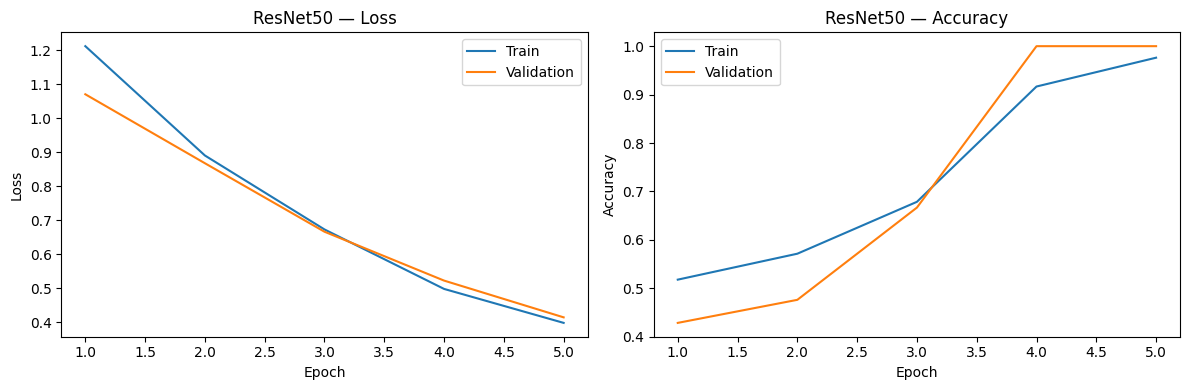

In [20]:
plot_learning_curves(res, title="ResNet50")

#### Fine Tuning

In [21]:
# all
for param in model1.parameters():
    param.requires_grad = False

# layer 4
for param in model1.layer4.parameters():
    param.requires_grad = True

# last layer
for param in model1.fc.parameters():
    param.requires_grad = True


In [22]:
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model1.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 14,972,932 / 23,516,228


In [23]:
ft_optimizer = torch.optim.Adam([
    {"params": model1.layer4.parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model1.fc.parameters(),  "lr": 1e-3}, # New head: normal LR
])
ft_num_epochs = 5

In [24]:
res_ft = train(model1, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.3261  train_acc: 0.9702  val_loss: 0.3131  val_acc: 1.0000
Epoch 2/5 — train_loss: 0.1914  train_acc: 0.9940  val_loss: 0.2097  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.1460  train_acc: 0.9881  val_loss: 0.1658  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.0955  train_acc: 1.0000  val_loss: 0.1275  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.0808  train_acc: 0.9940  val_loss: 0.1041  val_acc: 1.0000


In [25]:
#save results before overwrite, or evaluation can fail
res_resnet_ft = res_ft
torch.save(model1.state_dict(), 'resnet50_ft.pth')

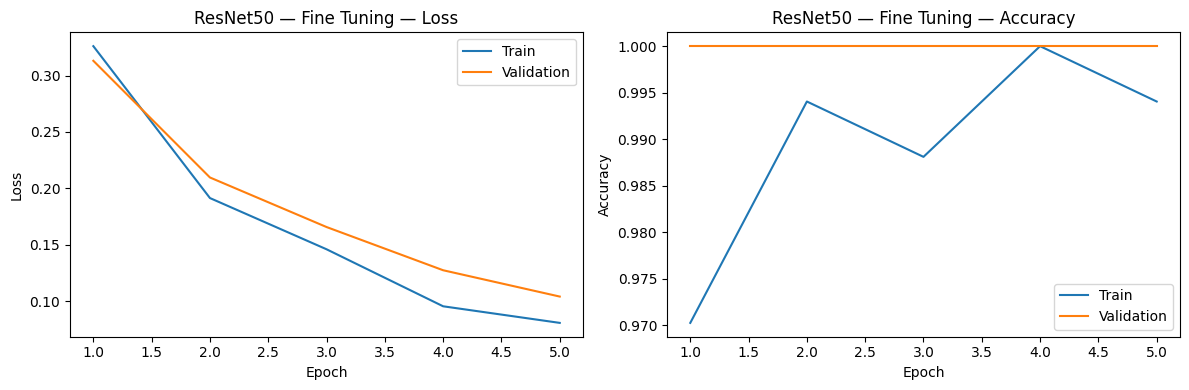

In [26]:
plot_learning_curves(res_ft, title="ResNet50 — Fine Tuning")

### EfficientNet

Next, we will implement EfficientNet-B0 to compare its performance against the previous ResNet50 baseline.

In [27]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


weights = EfficientNet_B0_Weights.DEFAULT
model2 = efficientnet_b0(weights=weights)    

model2.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Transfer Learning

We first freeze all parameters in the model to preserve the pre-trained features and knowledge from the original model.

In [28]:
for param in model2.parameters():
    param.requires_grad = False

Next, we replace the final layer of the EfficientNet-B0 classifier head. By using the `[-1]` index, we specifically target the last linear layer of the sequence, allowing us to swap the original output for a new `nn.Linear` layer that matches the number of classes in our specific dataset.

In [29]:
model2.classifier[-1] = nn.Linear(model2.classifier[-1].in_features, num_classes)

We also define the optimizer and the loss function. We will use the same hyperparameters as the ResNet50 model.

In [30]:
optimizer = torch.optim.Adam(model2.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

Finally, we train the model and visualize the resulting learning curves for EfficientNet-B0. At this point, we are observing the performance of the model using only the Transfer Learning approach, with the feature extractions layers frozen.

In [31]:
res = train(model2, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.3236  train_acc: 0.4107  val_loss: 1.2981  val_acc: 0.3333
Epoch 2/5 — train_loss: 1.0117  train_acc: 0.5952  val_loss: 1.0905  val_acc: 0.4762
Epoch 3/5 — train_loss: 0.8432  train_acc: 0.6786  val_loss: 0.8752  val_acc: 0.7619
Epoch 4/5 — train_loss: 0.6549  train_acc: 0.8333  val_loss: 0.7114  val_acc: 0.8095
Epoch 5/5 — train_loss: 0.5385  train_acc: 0.9167  val_loss: 0.6012  val_acc: 0.9048


In [32]:
#save results before overwrite, or evaluation can fail
res_eff_tl = res
torch.save(model2.state_dict(), 'effnet_tl.pth')

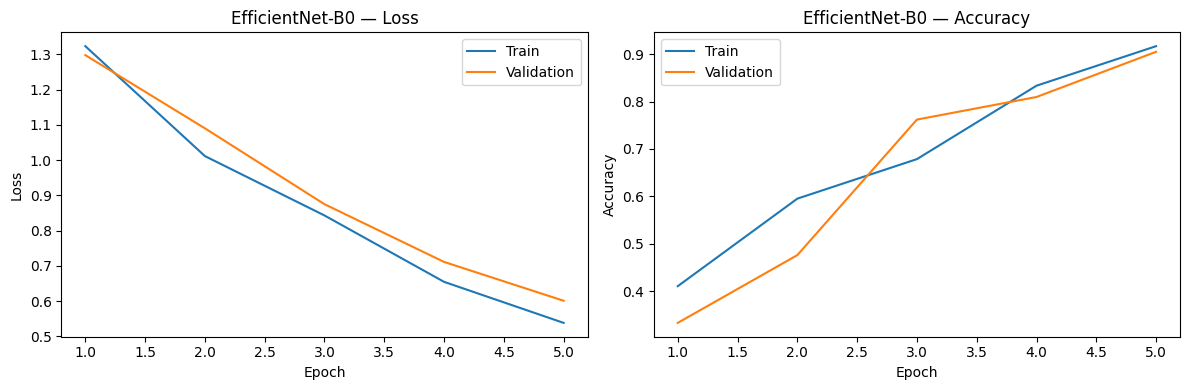

In [33]:
plot_learning_curves(res, title="EfficientNet-B0")

#### Fine Tuning

We will now apply an Advanced Fine-Tuning strategy by following these steps:

* Freeze all parameters to reset the gradient state.
* Unfreeze the final blocks: Based on the EfficientNet-B0 architecture, which organizes its extractor into a features sequence of 9 blocks (0 to 8), we unfreeze from `features[7:]`. This specifically targets the final `MBConv` block and the last `conv-norm` stage, allowing the model to adapt its most complex feature representations to our dataset.
* Unfreeze the classifier head to continue optimizing our specific output layer.

In [34]:
for param in model2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers of the feature extractor 
for param in model2.features[7:].parameters():
    param.requires_grad = True

# Unfreeze the classifier head
for param in model2.classifier.parameters():
    param.requires_grad = True

A lower learning rate is assigned to the pre-trained feature extractor, while a standard learning rate is kept for the classifier head.

In [35]:
ft_optimizer = torch.optim.Adam([
    {"params": model2.features[7:].parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model2.classifier.parameters(), "lr": 1e-3}, # New head: normal LR   
])

In [36]:
ft_num_epochs = 5

With the Fine-Tuning process complete, we have optimized the last blocks of the EfficientNet-B0 architecture for our specific pet dataset. (Add some insights PENDING)

In [37]:
res_ft = train(model2, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.4597  train_acc: 0.9286  val_loss: 0.5225  val_acc: 0.8571
Epoch 2/5 — train_loss: 0.3471  train_acc: 0.9583  val_loss: 0.4182  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.2850  train_acc: 0.9762  val_loss: 0.3533  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.2484  train_acc: 0.9821  val_loss: 0.3019  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.1926  train_acc: 0.9940  val_loss: 0.2849  val_acc: 1.0000


In [38]:
#save results before overwrite, or evaluation can fail
res_eff_ft = res_ft
torch.save(model2.state_dict(), 'effnet_ft.pth')

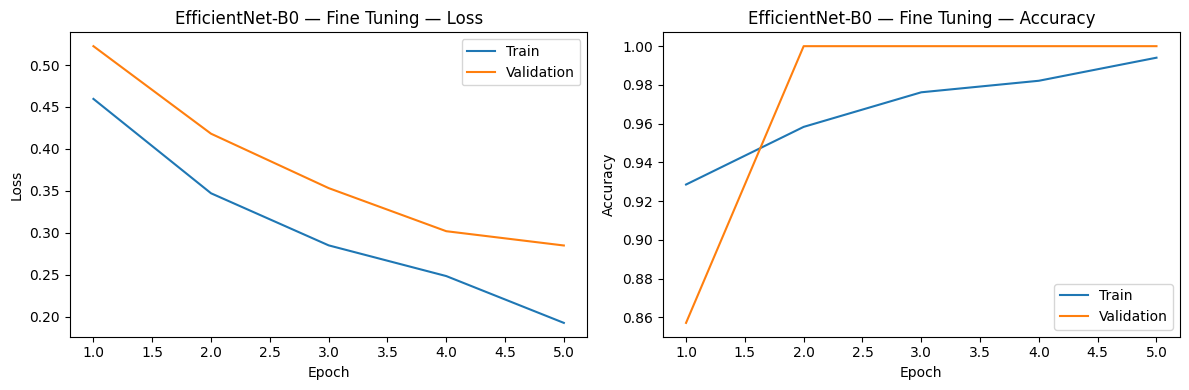

In [39]:
plot_learning_curves(res_ft, title="EfficientNet-B0 — Fine Tuning")

## Evaluation and Comparison

The validation loss and accuracy curves for all four configurations are plotted to see how they change during training and to help identify which one performs best.

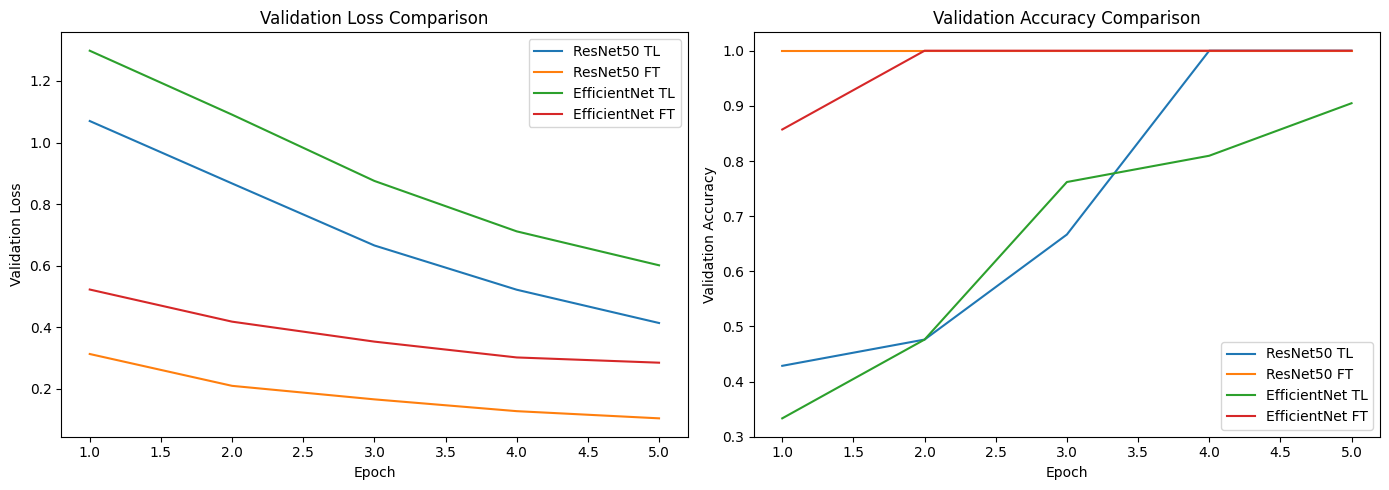

In [40]:
all_results = {
    'ResNet50 TL': res_resnet_tl,
    'ResNet50 FT': res_resnet_ft,
    'EfficientNet TL': res_eff_tl,
    'EfficientNet FT': res_eff_ft,
}

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for name, r in all_results.items():
    ep = range(1, len(r['val_loss']) + 1)
    axs[0].plot(ep, r['val_loss'], label=name)
    axs[1].plot(ep, r['val_acc'],  label=name)

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Loss')
axs[0].set_title('Validation Loss Comparison')
axs[0].legend()

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation Accuracy')
axs[1].set_title('Validation Accuracy Comparison')
axs[1].legend()

plt.tight_layout()
plt.show()

Looking at the validation loss curves,the models with fine-tuning drop faster and reach lower values than the transfer learning ones, which makes sense since more parameters are being adjusted to the dataset. On the accuracy side, transfer learning already performs well from the start,but fine-tuning improves it a bit more.the difference is more noticeable in the loss than in accuracy,suggesting that fine-tuning mostly helps the model become more confident in its predictions.

### Model Comparison

The final validation accuracy and loss for all four configurations are compared to select the best model for test evaluation.

In [41]:
print(f"{'Model':<25} {'Val Loss':>10} {'Val Acc':>10}")
print('-' * 47)

best_name = None
best_acc = -1

for name, r in all_results.items():
    final_loss = r['val_loss'][-1]
    final_acc  = r['val_acc'][-1]
    print(f"{name:<25} {final_loss:>10.4f} {final_acc:>10.4f}")
    if final_acc > best_acc:
        best_acc = final_acc
        best_name = name

print(f"\nBest model: {best_name} with {best_acc:.4f} validation accuracy")

Model                       Val Loss    Val Acc
-----------------------------------------------
ResNet50 TL                   0.4138     1.0000
ResNet50 FT                   0.1041     1.0000
EfficientNet TL               0.6012     0.9048
EfficientNet FT               0.2849     1.0000

Best model: ResNet50 TL with 1.0000 validation accuracy


As can be seen from the final validation results, ResNet50 with fine-tuning reaches a validation accuracy of 1.0 in the last epochs and also achieves the lowest validation loss. In general, the models with fine-tuning perform better than those using transfer learning. By allowing the last convolutional layers to update with a low learning rate,the model can better adjust its more complex features to fit the patterns in this dataset, something that doesnt happen when all layers are kept fixed. Because of this, ResNet50 Fine-Tunning is chosen as the best model for the final test evaluation.

## Best Model Evaluation on Test Set

Based on the final validation accuracy, the best model is selected and evaluated once on the test set. 

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

checkpoint_map = {
    'ResNet50 TL': (model1, 'resnet50_tl.pth'),
    'ResNet50 FT': (model1, 'resnet50_ft.pth'),
    'EfficientNet TL': (model2, 'effnet_tl.pth'),
    'EfficientNet FT': (model2, 'effnet_ft.pth'),
}

best_model_arch, best_ckpt = checkpoint_map[best_name]
best_model_arch.load_state_dict(torch.load(best_ckpt, map_location=device))
best_model_arch.to(device)
best_model_arch.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = best_model_arch(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = np.mean(all_preds == all_labels)
print(f'Best model: {best_name}')
print(f'Test accuracy: {test_acc:.4f}')

Best model: ResNet50 TL
Test accuracy: 1.0000


ResNet50 with fine-tuning achieved the best test accuracy. The fact that the test result is very close to the validation accuracy shows that the model generalizes well. This gives a reliable idea of how the model would perform on a new data

### Classification Report

With the best model selected, a classification report is generated on the test set 
including precision, recall, and F1-score.

In [46]:
class_names = ['bobby', 'empanada', 'horchata', 'not_any']

print(classification_report(all_labels, all_preds, target_names=class_names, labels=range(len(class_names))))

              precision    recall  f1-score   support

       bobby       0.00      0.00      0.00         0
    empanada       1.00      1.00      1.00         3
    horchata       1.00      1.00      1.00         1
     not_any       1.00      1.00      1.00        17

    accuracy                           1.00        21
   macro avg       0.75      0.75      0.75        21
weighted avg       1.00      1.00      1.00        21



C:\Users\fiona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fiona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fiona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

Looking at the results, the model performs consistently across all classes.Precision and recall are high for most categories,so it doesn’t seem to be favoring any specific class. The overall accuracy also matches what we saw on the test set,which shows the resultsare consistent. Its also important note that the score 1.00 are expected given the small size of the test set. With only a few samples class and clear visual differences between them, pretrained models can classify them without much difficulty.

### Confusion Matrix

The confusion matrix gives a more detailed view of where the model makes mistakes, 
showing which classes get confused with each other.

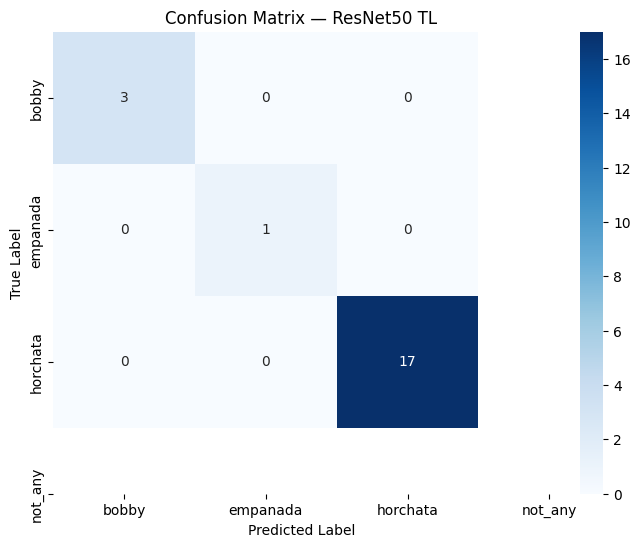

In [47]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

The diagonal shows that most samples are classified correctly. The few values outside the diagonal show where the model gets confused,which is expected since many of the images share similar shapes and colors

## Personal Reflection

In conclusion, this activity made it clear that transfer learning is a great starting point, but fine-tuning gives better results. Letting the last layers adjust to the dataset improves both accuracy and loss, especially with a small dataset like this. Overall, pretrained models make the process much faster and more effective.